# Case Study: Online Course Platform Analysis

### Business Problem
An online course platform wants to answer:
- Which course generates the highest revenue?
- Which month has the highest enrollments?
- How are course prices distributed?
- Do more enrollments lead to higher revenue?
- What percentage of revenue comes from each course category?

#### Dataset

In [3]:

data = {
    'Month': [
        'Jan','Jan',
        'Feb','Feb',
        'Mar','Mar',
        'Apr','Apr',
        'May','May'
    ],

    'Course': [
        'Python','SQL',
        'Excel','Power BI',
        'Python','SQL',
        'Excel','Power BI',
        'Python','Power BI'
    ],

    'Category': [
        'Programming','Database',
        'Analytics','Analytics',
        'Programming','Database',
        'Analytics','Analytics',
        'Programming','Analytics'
    ],

    'Enrollments': [
        120,80,
        100,90,
        140,85,
        110,100,
        150,120
    ],

    'Price': [
        3000,2500,
        2000,3500,
        3000,2500,
        2000,3500,
        3000,3500
    ]
}

In [4]:
import pandas as pd
from matplotlib import pyplot as plt

In [5]:
df = pd.DataFrame(data)

In [6]:
df

,Month,Course,Category,Enrollments,Price
0,Jan,Python,Programming,120,3000
1,Jan,SQL,Database,80,2500
2,Feb,Excel,Analytics,100,2000
3,Feb,Power BI,Analytics,90,3500
4,Mar,Python,Programming,140,3000
5,Mar,SQL,Database,85,2500
6,Apr,Excel,Analytics,110,2000
7,Apr,Power BI,Analytics,100,3500
8,May,Python,Programming,150,3000
9,May,Power BI,Analytics,120,3500


In [8]:
# Calculate revenue
df['Revenue'] = (df['Enrollments'] *df['Price'])

In [9]:
df

,Month,Course,Category,Enrollments,Price,Revenue
0,Jan,Python,Programming,120,3000,360000
1,Jan,SQL,Database,80,2500,200000
2,Feb,Excel,Analytics,100,2000,200000
3,Feb,Power BI,Analytics,90,3500,315000
4,Mar,Python,Programming,140,3000,420000
5,Mar,SQL,Database,85,2500,212500
6,Apr,Excel,Analytics,110,2000,220000
7,Apr,Power BI,Analytics,100,3500,350000
8,May,Python,Programming,150,3000,450000
9,May,Power BI,Analytics,120,3500,420000


### Task 1: Revenue by Course
- Which course generates the highest revenue?

In [10]:
# data preparation
course_Revenue=df.groupby('Course')['Revenue'].sum().reset_index()

In [11]:
course_Revenue

,Course,Revenue
0,Excel,420000
1,Power BI,1085000
2,Python,1230000
3,SQL,412500


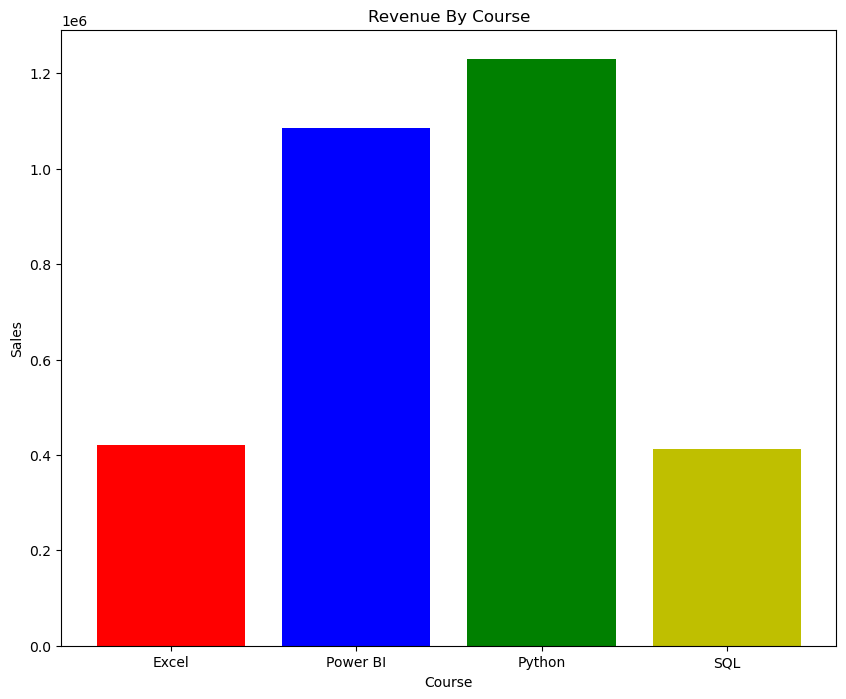

In [17]:
# Visualization
plt.figure(figsize=(10,8))
colors=['r','b','g','y']
plt.bar(course_Revenue['Course'], course_Revenue['Revenue'], color=colors)
plt.title('Revenue By Course')
plt.xlabel('Course')
plt.ylabel('Sales')
plt.show()

# 

### Task 2: Monthly Enrollments
- Which month has the highest student enrollments?

In [18]:
# data preparation
monthly_enrollments= df.groupby('Month')['Enrollments'].sum().reset_index()
monthly_enrollments

,Month,Enrollments
0,Apr,210
1,Feb,190
2,Jan,200
3,Mar,225
4,May,270


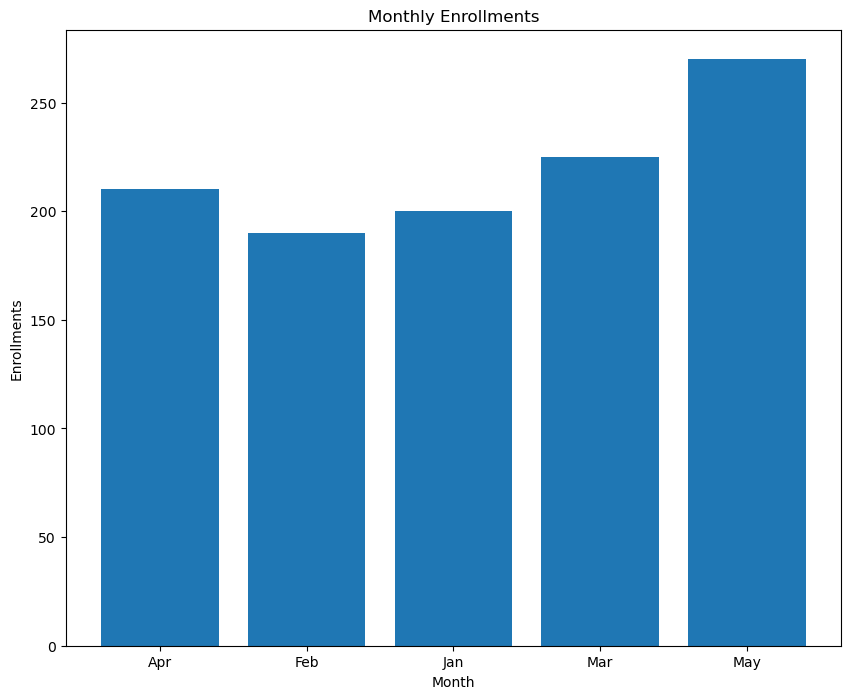

In [21]:
# Visualization
plt.figure(figsize=(10,8))
plt.bar(monthly_enrollments['Month'], monthly_enrollments['Enrollments'])
plt.title('Monthly Enrollments')
plt.xlabel('Month')
plt.ylabel('Enrollments')
plt.show()

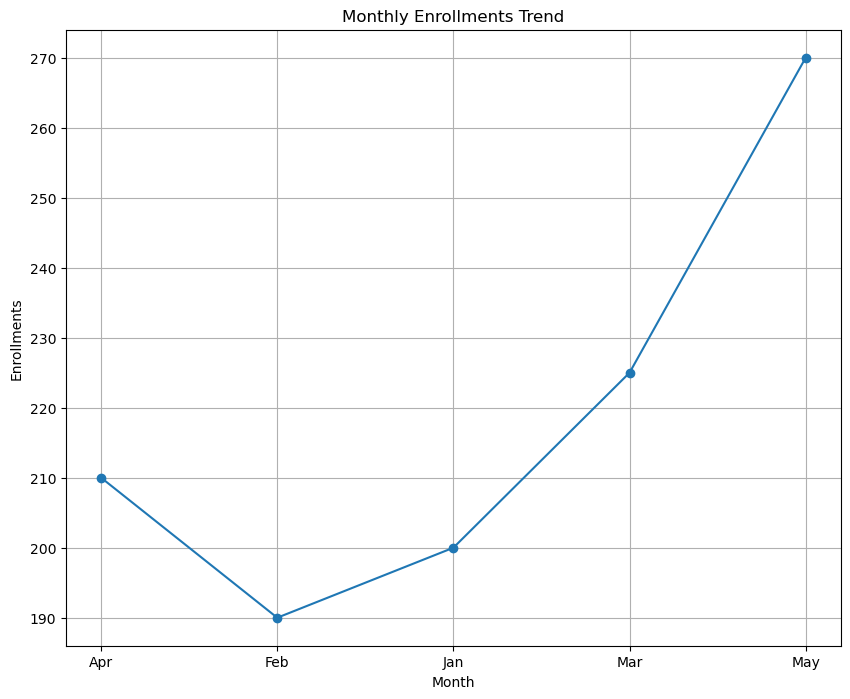

In [24]:
# Visualization
plt.figure(figsize=(10,8))
plt.plot(monthly_enrollments['Month'], monthly_enrollments['Enrollments'], marker='o')
plt.title('Monthly Enrollments Trend')
plt.xlabel('Month')
plt.ylabel('Enrollments')
plt.grid(True)
plt.show()

### Task 3: Course Price Distribution
- How are course prices distributed?

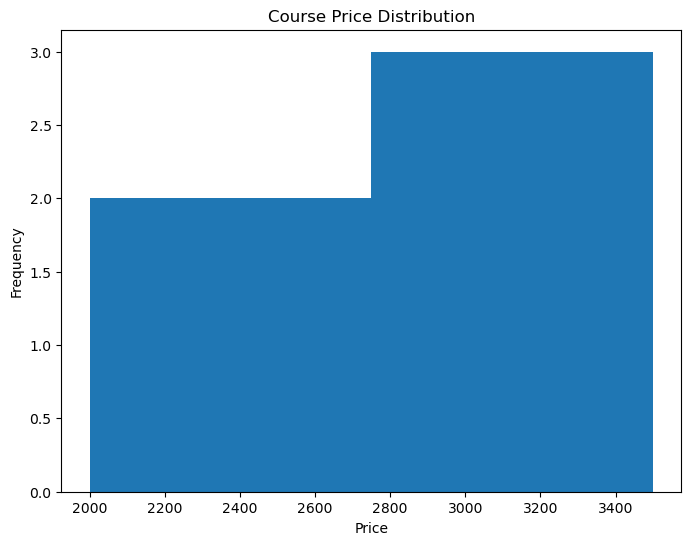

In [31]:
plt.figure(figsize=(8,6))
plt.hist(df['Price'], bins= 4)
plt.title('Course Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

### Task 4: Enrollments vs Revenue
- Do more enrollments lead to higher revenue?

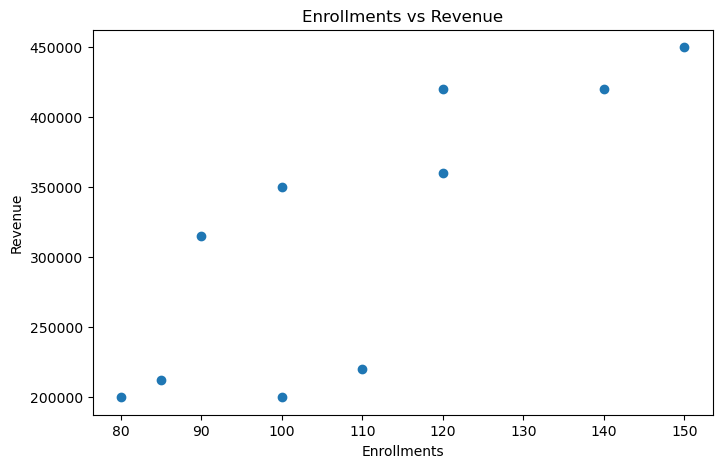

In [36]:
plt.figure(figsize=(8,5))
plt.scatter(df['Enrollments'],df['Revenue'])
plt.title('Enrollments vs Revenue')
plt.xlabel('Enrollments')
plt.ylabel('Revenue')
plt.show()

### Task 5: Revenue Share by Category
- How much revenue comes from each course category?

In [47]:
df.head()

,Month,Course,Category,Enrollments,Price,Revenue
0,Jan,Python,Programming,120,3000,360000
1,Jan,SQL,Database,80,2500,200000
2,Feb,Excel,Analytics,100,2000,200000
3,Feb,Power BI,Analytics,90,3500,315000
4,Mar,Python,Programming,140,3000,420000


In [49]:
# Data Preparation
category_revenue = (df.groupby('Category')['Revenue'].sum().reset_index())

In [50]:
category_revenue

,Category,Revenue
0,Analytics,1505000
1,Database,412500
2,Programming,1230000


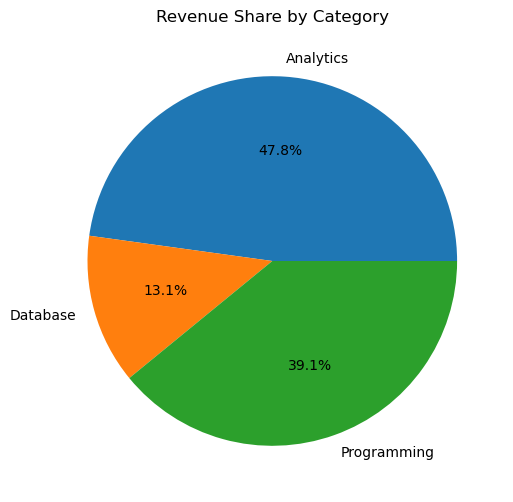

In [58]:
# Visualization
plt.figure(figsize=(6,6))
plt.pie(category_revenue['Revenue'], labels= category_revenue['Category'], autopct='%0.1f%%')
plt.title('Revenue Share by Category')
plt.show()